In [23]:
import pennylane as qml
import torch
import matplotlib.pyplot as plt

from itertools import combinations
from pennylane import numpy as np
from sklearn.datasets import load_breast_cancer
from sklearn.preprocessing import MaxAbsScaler
from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA
from torch.utils.data import DataLoader, TensorDataset

In [24]:
SEED = 42 # For reproducibility
torch.manual_seed(SEED)

# Quantum Neural Networks

A Quantum Neural Network (QNN) is a quantum machine learning model inspired by classical neural networks. Analogous to their classical counterparts, QNNs are fed with a classical input in the form of an array of numbers. This data then flows through a sequence of layers that perform transformations based on optimizable parameters. Finally, the processed data is output through a final layer. Let's see how QNNs apply these three stages:

**1. Data preparation**: in order to transform the classical inputs in form of arrays into quantum states, we need to design and apply a feature map.

**2. Data processing**: this stage consist of the application of a variational circuit, that is a quantum circuit that depends on some optimizable parameters. These variational circuits perform transformations in the input data (that have already been embedded into quantum states) and are usually structured in layers, as in classical neural networks.

**3. Data output**: in order to obtain a classical output we need to perform a quantum measurement to obtain the expectation values or probabilities.

These three stages allow us to design different architectures for our QNNs, making it essential to be intentional about every choice. The feature map, the ansatz, and the measurement operation must be tailored to our data characteristics and specific goals, as they will exert a critical influence on the model's performance. Data must be normalized according to the specific feature map in use, and the number of parameters must be kept as close as possible to the sweet spot between underfitting and overfitting.

The most typical features maps for QNNs are:

* **Angle encoding**: each classical feature is encoded as the angle of a quantum rotation gate. For example, a data point $x = (x_1, x_2, \dots, x_n)$ can be encoded by applying rotations such as $R_y(x_i)$ or $R_z(x_i)$ to different qubits. This is one of the simplest and most widely used encoding strategies, but the input data usually need to be normalized to a suitable angular range, such as $[0,\pi]$ or $[0,2\pi]$.

* **Amplitude encoding**: the classical data vector is encoded directly into the amplitudes of a quantum state. Given a normalized vector $x$, the corresponding quantum state can be written as

$$
|\psi(x)\rangle = \sum_i x_i |i\rangle.
$$

This encoding is efficient in terms of the number of qubits, since $n$ qubits can represent up to $2^n$ amplitudes. However, preparing an arbitrary amplitude-encoded state can be costly on real quantum hardware.

* **ZZ Feature Map**: this feature map encodes classical data using single-qubit rotations and two-qubit interaction terms based on Pauli-$Z$ operators. The main idea is to encode not only individual features, but also correlations between pairs of features through terms such as $x_i x_j$. This makes the map more expressive than simple angle encoding, although it usually requires deeper circuits with many two-qubit gates, which are more prone to errors on real quantum hardware.

Some examples of variational forms are:

* **Two-local**: this ansatz is built by alternating layers of parametrized single-qubit rotations and two-qubit entangling gates. For $n$ qubits and $k$ repetitions, it uses $n(k+1)$ trainable parameters, because it actually contains $k+1$ rotation layers. A typical version applies $R_y(\theta_{rj})$ gates to every qubit in each layer and CNOT gates between neighboring qubits to create entanglement. It is a versatile ansatz and can be combined with different measurement strategies.

* **Tree tensor**: this variational form follows a tree-like entanglement structure, where qubits are progressively combined through CNOT gates and parametrized rotations. For $n=2^k$ qubits, it contains $k+1$ layers, with fewer parameters at each new layer. This structure is usually shallower than fully connected ansatzes and is especially natural for binary classification tasks, where one can measure the expectation value of a single output qubit.

* **Strongly entangling layers**: this ansatz consists of repeated layers of general single-qubit rotations followed by entangling gates. Each layer usually applies rotations such as $R_z$, $R_y$ and $R_z$ to every qubit, giving $3nk$ trainable parameters for $n$ qubits and $k$ layers. The entangling gates connect qubits according to a chosen range or pattern, making the circuit highly expressive. However, this expressivity comes at the cost of deeper circuits and more two-qubit gates, which are more prone to noise on real quantum hardware.


Finally, as in classical neural networks, the optimization algorithm also plays an essential role in the model's training stage. We will use gradient descent algorithms with the Adam optimizer, so we need to compute the gradient of the expected value of a chosen loss function with respect to the optimizable parameters. The three main methods for calculating these gradients are:

* **Numerical approximation**: this method estimates the gradient by evaluating the model several times with slightly shifted parameter values. For a real-valued function $f:\mathbb{R}^n \rightarrow \mathbb{R}$, a simple finite-difference approximation of the partial derivative with respect to $x_j$ is

$$
\frac{\partial f}{\partial x_j}
\approx
\frac{f(x_1,\dots,x_j+h,\dots,x_n)-f(x_1,\dots,x_n)}{h},
$$

where $h$ is a small number. This method is general and easy to understand, but it can be inefficient because the quantum circuit must be evaluated many times.

* **Automatic differentiation**: when the QNN is executed on a simulator, classical automatic differentiation techniques can be used to compute gradients efficiently. This is similar to what is done in classical neural networks. The main advantage is that it can provide accurate gradients without manually deriving them. However, it is mainly useful in simulation, since real quantum hardware does not directly expose the internal state transformations needed for standard backpropagation.

* **Parameter shift rule**: this method allows gradients to be computed by running the same quantum circuit with shifted values of the trainable parameters. It is especially important because it can be used on real quantum hardware for many common parametrized gates. For example, if $E(\theta)$ is the expectation value obtained from a circuit containing a rotation gate depending on $\theta$, then its derivative can often be computed as

$$
\nabla_{\theta}E(\theta)
=
\frac{1}{2}
\left[
E\left(\theta+\frac{\pi}{2}\right)
-
E\left(\theta-\frac{\pi}{2}\right)
\right].
$$

This avoids purely numerical finite differences and provides an exact gradient formula for many standard quantum gates.

Another common strategy in QNN architectures is data reuploading. Instead of encoding the input data only once at the beginning of the circuit, the same classical features are embedded several times between variational layers. In this way, the circuit alternates between data encoding blocks and trainable transformations. This can increase the expressive power of the model, since the input data influence the quantum state at different stages of the computation. However, it also increases the circuit depth, so the number of reuploading layers must be chosen carefully to avoid unnecessary complexity and stronger sensitivity to noise.



# Dataset

We will use a real dataset with information about breast cancer using the `load_breast_cancer` function imported from `sklearn.datasets`.

In [25]:
# Load the data
x, y = load_breast_cancer(return_X_y=True)

# Split into train and test
x_tr, x_tmp, y_tr, y_tmp = train_test_split(
    x, y, test_size=0.1, stratify=y, random_state=SEED
)

x_val, x_test, y_val, y_test = train_test_split(
    x_tmp, y_tmp, test_size=0.5, stratify=y_tmp, random_state=SEED
)

# Normalization of the data
scaler = MaxAbsScaler()

x_tr = scaler.fit_transform(x_tr)
x_test = scaler.transform(x_test)
x_val = scaler.transform(x_val)

x_test = np.clip(x_test, 0, 1)
x_val = np.clip(x_val, 0, 1)

# Get info about the dataset
print(f"The dataset contains {x_tr.shape[0]} rows with {x_tr.shape[1]} features")

The dataset contains 512 rows with 30 features


We will use `PCA` to reduce the dimensionality of the features to four dimensions.

In [26]:
# Define the PCA
pca = PCA(n_components=4)

# Use fit transform on train and fit on data and test
xs_tr = pca.fit_transform(x_tr)
xs_test = pca.transform(x_test)
xs_val = pca.transform(x_val)

In [27]:
# Convert data to torch tensors
x_train_t = torch.from_numpy(xs_tr).float()
y_train_t = torch.from_numpy(y_tr).float()

x_val_t = torch.from_numpy(xs_val).float()
y_val_t = torch.from_numpy(y_val).float()

x_test_t = torch.from_numpy(xs_test).float()
y_test_t = torch.from_numpy(y_test).float()

# Load data
train_dataset = TensorDataset(x_train_t, y_train_t)
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)

# Implementing QNNs with PennyLane

We will build a QNN by using a ZZ Feature Map with a Two Local ansatz and since we are working with binary classification, we will use the observable $M=| 0 \rangle \langle 0 |$.

In [ ]:
def ZZFeatureMap(nqubits: int, data: list[float]) -> None:
    """
    Builds a ZZ feature map using PennyLane.
    """
    # Number of variable that we will load
    nload = min(nqubits, data.shape[-1])

    # Encode individual features
    for i in range(nload):
        qml.Hadamard(i)
        qml.RZ(2.0 * data[..., i], wires = i)  # Use [..., i] because we will use batches

    # Encode pairwise feature interactions
    for q0, q1 in list(combinations(range(nload), 2)):
        angle = 2.0 * (np.pi - data[..., q0]) * (np.pi - data[..., q1])

        qml.CNOT(wires=[q0, q1])
        qml.RZ(angle, wires=q1)
        qml.CNOT(wires=[q0, q1])
        
def TwoLocal(nqubits: int, theta: list[float], reps: int) -> None:
    """
    Builds a two-local variational ansatz using PennyLane.
    """
    # Initial rotation layer
    for i in range(nqubits):
        qml.RY(theta[i], wires=i)

    # Entangling and rotation layers
    for rep in range(reps):
        # Linear CNOT entanglement
        for i in range(nqubits-1):
            qml.CNOT(wires = [i, i+1])
        # New rotation layer
        for i in range(nqubits):
            qml.RY(theta[i+(rep+1)*nqubits], wires=i)

In [ ]:
# Build the QNN function
nqubits = 4
nreps = 1
dev = qml.device("lightning.qubit", wires = nqubits)

def qnn_circ(inputs: list[float], theta: list[float]) -> None:
    """
    Builds a QNN circuit in Pennylane using a ZZ Feature Map, a Two local ansantz
    and the observable M = |0><0| for the measurement.
    """
    ZZFeatureMap(nqubits, inputs)
    TwoLocal(nqubits, theta, nreps)
    return qml.expval(qml.Projector([0], wires=0))

qnn = qml.QNode(func=qnn_circ, device=dev, interface="torch")

In [ ]:
# Define the trainable parameter shapes of the QNN
weights = {"theta": ((nreps+1)*nqubits,)}  # 8 parameters

# Convert the PennyLane QNode into a PyTorch layer
qlayer = qml.qnn.TorchLayer(qnn, weights)

# Build the PyTorch model
model = torch.nn.Sequential(qlayer)
model.double()


# Training loop with early stopping
epochs = 100
patience = 3
learning_rate = 0.005
best_val_loss = float("inf")
best_state = None
patience_counter = 0

# Define optimizer and loss function
opt = torch.optim.Adam(model.parameters(), lr=learning_rate)
loss_fn = torch.nn.BCELoss()


history = {"loss": [], "val_loss": []}

for epoch in range(epochs):
    model.train()
    train_losses = []

    for xb, yb in train_loader:
        opt.zero_grad()

        # Forward pass
        preds = model(xb).reshape(-1)

        # Compute loss
        loss = loss_fn(preds, yb)

        # Backpropagation
        loss.backward()
        opt.step()

        train_losses.append(loss.item())

    # Validation
    model.eval()
    with torch.no_grad():
        val_preds = model(x_val_t).reshape(-1)
        val_loss = loss_fn(val_preds, y_val_t)

    train_loss = sum(train_losses) / len(train_losses)
    val_loss_value = val_loss.item()

    history["loss"].append(train_loss)
    history["val_loss"].append(val_loss_value)

    print(
        f"Epoch {epoch + 1}: "
        f"loss={train_loss:.4f}, "
        f"val_loss={val_loss_value:.4f}"
    )

    # Save best model
    if val_loss_value <= best_val_loss:
        best_val_loss = val_loss_value
        best_state = {
            name: param.detach().clone()
            for name, param in model.state_dict().items()
        }
        patience_counter = 0
    else:
        patience_counter += 1

    # Early stopping
    if patience_counter >= patience:
        print("Early stopping")
        break

# Restore best model
if best_state is not None:
    model.load_state_dict(best_state)

Epoch 1: loss=0.7174, val_loss=0.7443
Epoch 2: loss=0.7118, val_loss=0.7390
Epoch 3: loss=0.7064, val_loss=0.7341
Epoch 4: loss=0.7017, val_loss=0.7294
Epoch 5: loss=0.6970, val_loss=0.7252
Epoch 6: loss=0.6928, val_loss=0.7214
Epoch 7: loss=0.6893, val_loss=0.7180
Epoch 8: loss=0.6862, val_loss=0.7149
Epoch 9: loss=0.6835, val_loss=0.7120
Epoch 10: loss=0.6810, val_loss=0.7095
Epoch 11: loss=0.6790, val_loss=0.7073
Epoch 12: loss=0.6771, val_loss=0.7054
Epoch 13: loss=0.6757, val_loss=0.7036
Epoch 14: loss=0.6743, val_loss=0.7020
Epoch 15: loss=0.6732, val_loss=0.7005
Epoch 16: loss=0.6721, val_loss=0.6992
Epoch 17: loss=0.6712, val_loss=0.6980
Epoch 18: loss=0.6704, val_loss=0.6969
Epoch 19: loss=0.6698, val_loss=0.6958
Epoch 20: loss=0.6690, val_loss=0.6950
Epoch 21: loss=0.6686, val_loss=0.6940
Epoch 22: loss=0.6679, val_loss=0.6932
Epoch 23: loss=0.6674, val_loss=0.6924
Epoch 24: loss=0.6670, val_loss=0.6915
Epoch 25: loss=0.6665, val_loss=0.6907
Epoch 26: loss=0.6660, val_loss=0.

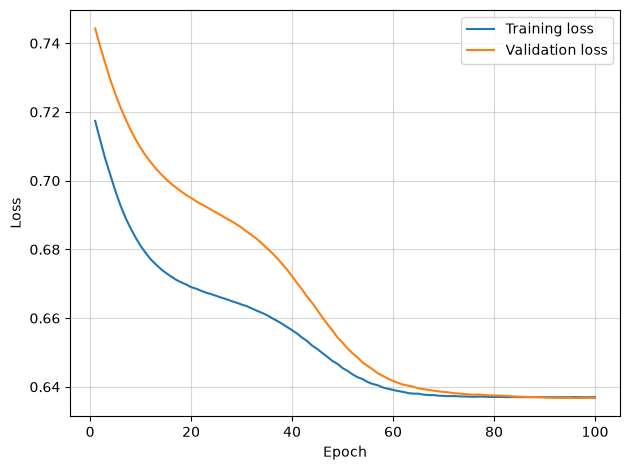

In [31]:
def plot_losses(history) -> None:
    """
    Plots the training and validation curves from the history of a model
    """
    tr_loss = history["loss"]
    val_loss = history["val_loss"]
    epochs = np.array(range(len(tr_loss))) + 1
    plt.plot(epochs, tr_loss, label="Training loss")
    plt.plot(epochs, val_loss, label="Validation loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    plt.grid(alpha=0.5)
    plt.tight_layout()
    plt.show()

plot_losses(history)

In [32]:
# Evaluate the precision of the model in all the datasets
model.eval()
with torch.no_grad():
    train_probs = model(x_train_t).squeeze()
    train_preds = (train_probs >= 0.5).double()
    train_acc = (train_preds == y_train_t).double().mean().item()

    val_probs = model(x_val_t).squeeze()
    val_preds = (val_probs >= 0.5).double()
    val_acc = (val_preds == y_val_t).double().mean().item()

    test_probs = model(x_test_t).squeeze()
    test_preds = (test_probs >= 0.5).double()
    test_acc = (test_preds == y_test_t).double().mean().item()

print(f"Train accuracy: {100*train_acc:.2f}%")
print(f"Val accuracy: {100*val_acc:.2f}%")
print(f"Test accuracy: {100*test_acc:.2f}%")

Train accuracy: 66.80%
Val accuracy: 64.29%
Test accuracy: 68.97%


The model obtains similar accuracies on the training, validation and test sets. This suggests that the model is not strongly overfitting the training data, because its performance does not collapse when evaluated on unseen examples. However, the accuracy is still relatively modest, around the mid-to-high 60% range, so the model is also not learning a very strong decision boundary.

Let's now use the `StronglyEntanglingLayers` and compare the results.

In [38]:
# Build the QNN function
nqubits = 4
nreps = 4 
dev = qml.device("lightning.qubit", wires = nqubits)

weights_dim = qml.StronglyEntanglingLayers.shape(
    n_layers=nreps,
    n_wires=nqubits
)

def qnn_circ_strong(inputs: list[float], theta: list[float]) -> None:
    """
    Builds a QNN circuit in Pennylane using a ZZ Feature Map, a StronglyEntanglingLayers 
    ansantz and the observable M = |0><0| for the measurement.
    """
    ZZFeatureMap(nqubits, inputs)
    theta1 = theta.reshape(weights_dim)
    qml.StronglyEntanglingLayers(
        weights=theta1,
        wires=range(nqubits)
    )
    return qml.expval(qml.Projector([0], wires=0))

qnn = qml.QNode(func=qnn_circ, device=dev, interface="torch")

In [ ]:
# Define the trainable parameter shapes of the QNN
weights = {"theta": (3*nreps*nqubits,)}  

# Convert the PennyLane QNode into a PyTorch layer
qlayer = qml.qnn.TorchLayer(qnn, weights)

# Build the PyTorch model
model = torch.nn.Sequential(qlayer)
model.double()


# Training loop with early stopping
epochs = 100
patience = 3
learning_rate = 0.005
best_val_loss = float("inf")
best_state = None
patience_counter = 0

# Define optimizer and loss function
opt = torch.optim.Adam(model.parameters(), lr=learning_rate)
loss_fn = torch.nn.BCELoss()


history = {"loss": [], "val_loss": []}

for epoch in range(epochs):
    model.train()
    train_losses = []

    for xb, yb in train_loader:
        opt.zero_grad()

        # Forward pass
        preds = model(xb).reshape(-1)

        # Compute loss
        loss = loss_fn(preds, yb)

        # Backpropagation
        loss.backward()
        opt.step()

        train_losses.append(loss.item())

    # Validation
    model.eval()
    with torch.no_grad():
        val_preds = model(x_val_t).reshape(-1)
        val_loss = loss_fn(val_preds, y_val_t)

    train_loss = sum(train_losses) / len(train_losses)
    val_loss_value = val_loss.item()

    history["loss"].append(train_loss)
    history["val_loss"].append(val_loss_value)

    print(
        f"Epoch {epoch + 1}: "
        f"loss={train_loss:.4f}, "
        f"val_loss={val_loss_value:.4f}"
    )

    # Save best model
    if val_loss_value <= best_val_loss:
        best_val_loss = val_loss_value
        best_state = {
            name: param.detach().clone()
            for name, param in model.state_dict().items()
        }
        patience_counter = 0
    else:
        patience_counter += 1

    # Early stopping
    if patience_counter >= patience:
        print("Early stopping")
        break

# Restore best model
if best_state is not None:
    model.load_state_dict(best_state)

Epoch 1: loss=0.7299, val_loss=0.7116
Epoch 2: loss=0.7236, val_loss=0.7066
Epoch 3: loss=0.7174, val_loss=0.7018
Epoch 4: loss=0.7119, val_loss=0.6975
Epoch 5: loss=0.7057, val_loss=0.6939
Epoch 6: loss=0.7003, val_loss=0.6907
Epoch 7: loss=0.6959, val_loss=0.6879
Epoch 8: loss=0.6911, val_loss=0.6856
Epoch 9: loss=0.6873, val_loss=0.6837
Epoch 10: loss=0.6839, val_loss=0.6820
Epoch 11: loss=0.6808, val_loss=0.6808
Epoch 12: loss=0.6779, val_loss=0.6798
Epoch 13: loss=0.6756, val_loss=0.6791
Epoch 14: loss=0.6735, val_loss=0.6784
Epoch 15: loss=0.6721, val_loss=0.6780
Epoch 16: loss=0.6702, val_loss=0.6777


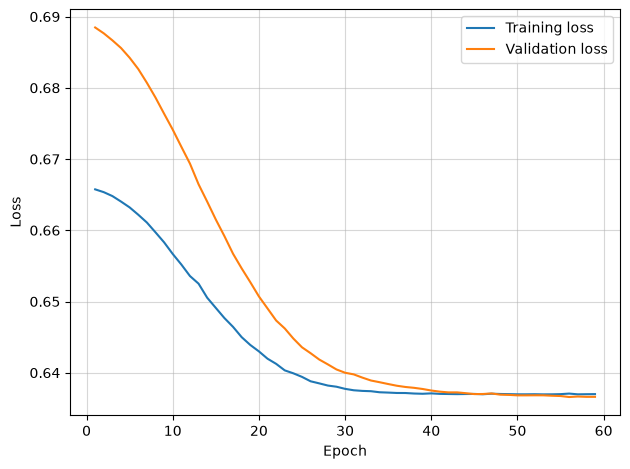

In [ ]:
plot_losses(history)

In [ ]:
# Evaluate the precision of the model in all the datasets
model.eval()
with torch.no_grad():
    train_probs = model(x_train_t).squeeze()
    train_preds = (train_probs >= 0.5).double()
    train_acc = (train_preds == y_train_t).double().mean().item()

    val_probs = model(x_val_t).squeeze()
    val_preds = (val_probs >= 0.5).double()
    val_acc = (val_preds == y_val_t).double().mean().item()

    test_probs = model(x_test_t).squeeze()
    test_preds = (test_probs >= 0.5).double()
    test_acc = (test_preds == y_test_t).double().mean().item()

print(f"Train accuracy: {100*train_acc:.2f}%")
print(f"Val accuracy: {100*val_acc:.2f}%")
print(f"Test accuracy: {100*test_acc:.2f}%")

Train accuracy: 66.99%
Val accuracy: 64.29%
Test accuracy: 68.97%
